In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/study-deep-learning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/study-deep-learning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/study-deep-learning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/study-deep-learning/7
    print("準備完了！このまま下のセルを実行できます。")

# 第7章 勾配降下法 (Gradient Descent)
## 7.2 勾配降下法による最適化 (Gradient Descent Optimization)

### 本節の概要と位置づけ
前節（7.1節）では、重み空間における誤差関数の幾何学的構造および定常点近傍での局所2次近似（Local Quadratic Approximation）を学びました。ニューラルネットワークの誤差関数 $E(\mathbf{w})$ に対して解析的に停留点方程式 $\nabla E(\mathbf{w}) = \mathbf{0}$ を解くことは不可能であるため、反復的な数値解法（Iterative Numerical Procedures）が必要不可欠となります。

多くの最適化手法は、何らかの初期値 $\mathbf{w}^{(0)}$ を選定したのち、重み空間内を以下の一般的な更新規則に従って逐次的に移動します：
$$
\mathbf{w}^{(\tau)} = \mathbf{w}^{(\tau-1)} + \Delta \mathbf{w}^{(\tau-1)} \tag{7.15}
$$
ここで $\tau$ は反復ステップを表し、アルゴリズムごとに更新量 $\Delta \mathbf{w}^{(\tau-1)}$ の選定方法が異なります。

本節（7.2節）では、ニューラルネットワーク最適化の根幹をなす以下の5つの重要トピックを数理的・統計的に詳解し、Pythonによる実験的検証を行います：
1. **勾配情報の利用 (7.2.1項)**: 誤差逆伝播法（Backpropagation）による勾配計算 $\mathcal{O}(W)$ と、関数評価のみの手法 $\mathcal{O}(W^3)$ に対する計算複雑度の圧倒的優位性 $\mathcal{O}(W^2)$。
2. **バッチ勾配降下法 (7.2.2項)**: 全訓練データセットを用いた最急降下更新 $\mathbf{w}^{(\tau)} = \mathbf{w}^{(\tau-1)} - \eta \nabla E(\mathbf{w}^{(\tau-1)})$ (Eq 7.16)。
3. **確率的勾配降下法 (SGD) (7.2.3項)**: 個別サンプルごとの逐次更新 $\mathbf{w}^{(\tau)} = \mathbf{w}^{(\tau-1)} - \eta \nabla E_n(\mathbf{w}^{(\tau-1)})$ (Eq 7.18)、**アルゴリズム 7.1**、データ冗長性の効率的処理、局所的最小値からの脱出能力。
4. **ミニバッチ法 (7.2.4項)**: サブセットサイズ $B$ による勾配推定、標本平均誤差の統計的スケール $\sigma / \sqrt{B}$、収穫逓減（Diminishing Returns）、ハードウェア効率（2のべき乗）、**アルゴリズム 7.2**。
5. **パラメータの初期化 (7.2.5項)**: 対称性の破れ（Symmetry Breaking）、ReLUネットワークに対する **He初期化** $\epsilon = \sqrt{2/M}$ の導出 (Eq 7.19–7.23)、Glorot/Xavier初期化、深層伝播における信号分散の維持。


In [1]:
# 環境セットアップと共通モジュールのインポート
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートの設定
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, "..")) if os.path.basename(current_dir) == "7" else current_dir
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from common.gradient_descent import (
    count_independent_quadratic_parameters,
    gradient_vs_function_eval_effort,
    batch_gradient_descent,
    stochastic_gradient_descent,
    minibatch_gradient_descent,
    compute_gradient_noise_vs_batch_size,
    he_normal_init,
    he_uniform_init,
    glorot_normal_init,
    glorot_uniform_init,
    zero_init,
    verify_symmetry_breaking,
    simulate_variance_propagation,
    generate_minibatch_noise_figure,
    generate_variance_propagation_figure,
    generate_gd_comparison_figure,
)
from common.plot_utils import setup_style

setup_style()
print("All common modules imported successfully.")


All common modules imported successfully.


---

## 7.2.1 勾配情報の利用 (Use of Gradient Information)

深層ニューラルネットワークにおいて誤差関数の勾配 $\nabla E(\mathbf{w})$ は、誤差逆伝播法（Error Backpropagation, 第8章）により効率的に計算可能です。勾配情報を用いることで、ネットワーク訓練の計算コストは劇的に削減されます。

### 局所2次近似のパラメータ数 (演習問題 7.7)
重みベクトル $\mathbf{w}$ の次元を $W$（全学習可能パラメータ数）とします。局所2次近似：
$$
E(\mathbf{w}) \simeq E(\widehat{\mathbf{w}}) + \mathbf{b}^T (\mathbf{w} - \widehat{\mathbf{w}}) + \frac{1}{2} (\mathbf{w} - \widehat{\mathbf{w}})^T \mathbf{H} (\mathbf{w} - \widehat{\mathbf{w}})
$$
において、最小値の位置を決定するために必要な独立な情報量は次のように決まります：
- 線形項のベクトル $\mathbf{b}$ は $W$ 個の独立な要素をもつ。
- ヘッセ行列 $\mathbf{H}$ は対称行列（$H_{ij} = H_{ji}$）であるため、独立な要素の数は $\frac{W(W+1)}{2}$ 個である。

したがって、2次曲面を完全に決定する独立なパラメータの総数は：
$$
W + \frac{W(W+1)}{2} = \frac{W(W+3)}{2} \tag{Exercise 7.7}
$$
となります。したがって、最小値を特定するには $\mathcal{O}(W^2)$ 個の独立な情報量を収集する必要があります。

### 計算複雑度の比較
1. **勾配情報を用いない場合 (関数評価のみ)**:
   - 最小値を特定するために $\mathcal{O}(W^2)$ 回の関数評価が必要となる。
   - 1回の順伝播（関数評価）には $\mathcal{O}(W)$ のステップを要する。
   - 必要な総計算量は **$\mathcal{O}(W^3)$** となる。
2. **勾配情報（誤差逆伝播法）を用いる場合**:
   - 勾配ベクトル $\nabla E$ は長さ $W$ のベクトルであり、1回の評価で $W$ 個の独立な情報をもたらす。
   - したがって、最小値を特定するのに必要な勾配評価回数はわずか $\mathcal{O}(W)$ 回である。
   - 誤差逆伝播法により、勾配評価1回あたりの計算量は順伝播と同等の $\mathcal{O}(W)$ ステップで完了する。
   - 必要な総計算量は **$\mathcal{O}(W^2)$** で済む。

パラメータ数 $W$ が数十万〜数億に達する深層学習において、$\mathcal{O}(W^3)$ と $\mathcal{O}(W^2)$ の差は計算可能性そのものを決定づけます。


In [2]:
# 7.2.1項: 計算複雑度と独立パラメータ数のスケーリング検証
import pandas as pd

w_dims = [10, 100, 1000, 10000, 100000]
records = []

for W in w_dims:
    effort = gradient_vs_function_eval_effort(W)
    records.append({
        "パラメータ次元 W": f"{W:,}",
        "独立パラメータ数 W(W+3)/2": f"{effort['independent_pieces_of_info']:,}",
        "勾配なし 計算ステップ O(W^3)": f"{effort['no_grad_total_steps']:.1e}",
        "勾配あり 計算ステップ O(W^2)": f"{effort['with_grad_total_steps']:.1e}",
        "高速化倍率 (W倍)": f"{W:,} 倍"
    })

df_scaling = pd.DataFrame(records)
print("=== 勾配情報利用による計算量削減の理論値比較 ===")
print(df_scaling.to_string(index=False))


=== 勾配情報利用による計算量削減の理論値比較 ===
パラメータ次元 W 独立パラメータ数 W(W+3)/2 勾配なし 計算ステップ O(W^3) 勾配あり 計算ステップ O(W^2) 高速化倍率 (W倍)
       10                65            1.0e+03            1.0e+02       10 倍
      100             5,150            1.0e+06            1.0e+04      100 倍
    1,000           501,500            1.0e+09            1.0e+06    1,000 倍
   10,000        50,015,000            1.0e+12            1.0e+08   10,000 倍
  100,000     5,000,150,000            1.0e+15            1.0e+10  100,000 倍


---

## 7.2.2 バッチ勾配降下法 (Batch Gradient Descent)

勾配情報を活用する最も基本的な手法は、負の勾配方向（誤差関数の最大減少方向）へ微小ステップを進めることです：
$$
\mathbf{w}^{(\tau)} = \mathbf{w}^{(\tau-1)} - \eta \nabla E(\mathbf{w}^{(\tau-1)}) \tag{7.16}
$$
ここでパラメータ $\eta > 0$ は**学習率（Learning Rate）**と呼ばれます。
誤差関数 $E(\mathbf{w})$ は全訓練データセットに対して定義されており、各ステップで全データセットを走査して勾配を計算するため、この手法は**バッチ法（Batch Methods）**と呼ばれます。

---

## 7.2.3 確率的勾配降下法 (Stochastic Gradient Descent, SGD)

データセットが巨大化すると、バッチ法は極めて非効率になります。独立な観測値に基づく最尤推定の誤差関数は、各データ点ごとの誤差 $E_n(\mathbf{w})$ の総和として表されます：
$$
E(\mathbf{w}) = \sum_{n=1}^N E_n(\mathbf{w}) \tag{7.17}
$$
**確率的勾配降下法 (SGD)** では、1つのデータ点 $n$ に基づいてパラメータを逐次的に更新します：
$$
\mathbf{w}^{(\tau)} = \mathbf{w}^{(\tau-1)} - \eta \nabla E_n(\mathbf{w}^{(\tau-1)}) \tag{7.18}
$$
全データセットを一通り走査することを**訓練エポック（Training Epoch）**と呼びます。

```
=============================================================================
アルゴリズム 7.1: 確率的勾配降下法 (Stochastic gradient descent)
=============================================================================
入力: データ点インデックス n in {1, ..., N} で表される訓練データセット
      データ点ごとの誤差関数 E_n(w)
      学習率パラメータ eta
      初期重みベクトル w
出力: 最終重みベクトル w

n <- 1
repeat
    w <- w - eta * grad E_n(w)      // 重みベクトルの更新
    n <- n + 1 (mod N)              // データの反復
until 収束
return w
=============================================================================
```

### SGDの主な利点
1. **データ冗長性の効率的処理**:
   データセット内の全サンプルを2倍に複製した極端な例を考えます。バッチ法では勾配評価の計算量が2倍に増大しますが、SGDは個別サンプルごとに更新を行うため、計算努力に無駄が生じません。
2. **局所的最小値からの脱出能力**:
   全データセットの誤差関数 $E(\mathbf{w})$ の定常点（局所最小値など）は、個々のデータ点 $E_n(\mathbf{w})$ の定常点とは一般に一致しません。単一サンプルの勾配が持つ確率的ノイズ（変動）により、浅い局所最小値や鞍点から抜け出すことができます。


---

## 7.2.4 ミニバッチ法 (Mini-batches)

単一データ点による勾配 $\nabla E_n(\mathbf{w})$ は、全データセット勾配に対する非常にノイズの大きい推定量となります。そこで、中間的なアプローチとして、小さな部分集合（**ミニバッチ**, サイズ $B$）を用いて勾配を評価します。

### 標本平均の誤差と収穫逓減 (演習問題 7.8)
$B$ 個のサンプルから平均を計算する際の標準誤差は、中心極限定理および大数の法則より次のように与えられます：
$$
\text{SE} = \frac{\sigma}{\sqrt{B}} \tag{7.2.4}
$$
ここで $\sigma$ はデータの母集団標準偏差です。
これは、バッチサイズ $B$ を増大させたときの真の勾配推定精度に**収穫逓減（Diminishing Returns）**が存在することを示しています。例えば、バッチサイズを **100倍** に増やしても、推定誤差は **10分の1**（$\sqrt{100} = 10$）にしかなりません。

さらに、GPUやTPUなどの現代の並列計算ハードウェアでは、**2のべき乗**（64, 128, 256, 512 など）のミニバッチサイズがテンソルコア演算器を最も効率よく稼働させます。また、各エポック開始時にデータセット全体をランダムにシャッフル（再配置）することで、データの順序相関を排除し、偏りを防ぎます。

```
=============================================================================
アルゴリズム 7.2: ミニバッチ確率的勾配降下法 (Mini-batch stochastic gradient descent)
=============================================================================
入力: データ点インデックス n in {1, ..., N} で表される訓練データセット
      バッチサイズ B
      ミニバッチごとの誤差関数 E_{n:n+B-1}(w)
      学習率パラメータ eta
      初期重みベクトル w
出力: 最終重みベクトル w

n <- 1
repeat
    w <- w - eta * grad E_{n:n+B-1}(w)   // 重みベクトルの更新
    n <- n + B
    if n > N then
        データをシャッフル
        n <- 1
    end if
until 収束
return w
=============================================================================
```


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_2_minibatch_noise.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_2_minibatch_noise.png
Mini-batch noise scaling figure saved: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_2_minibatch_noise.png


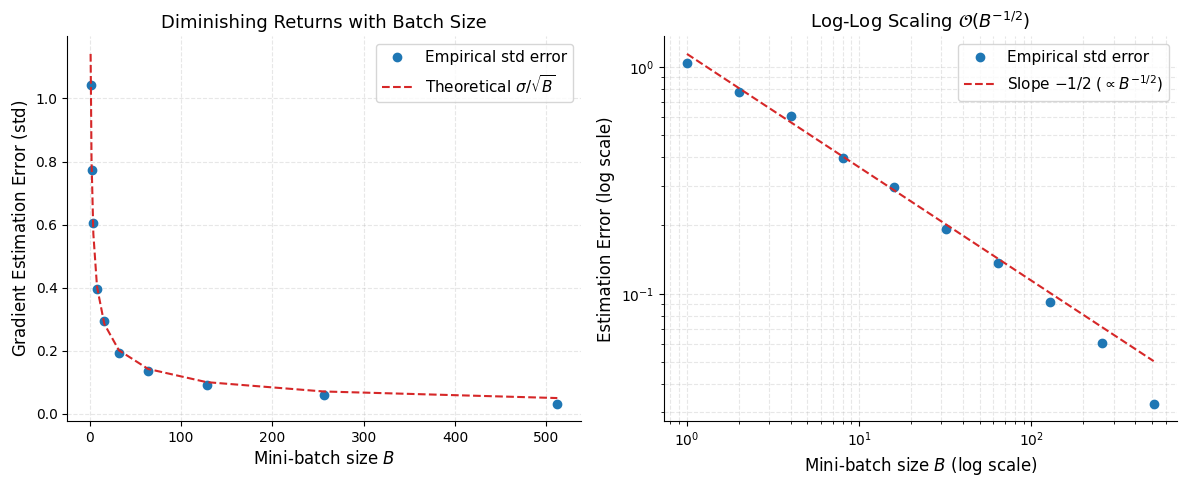

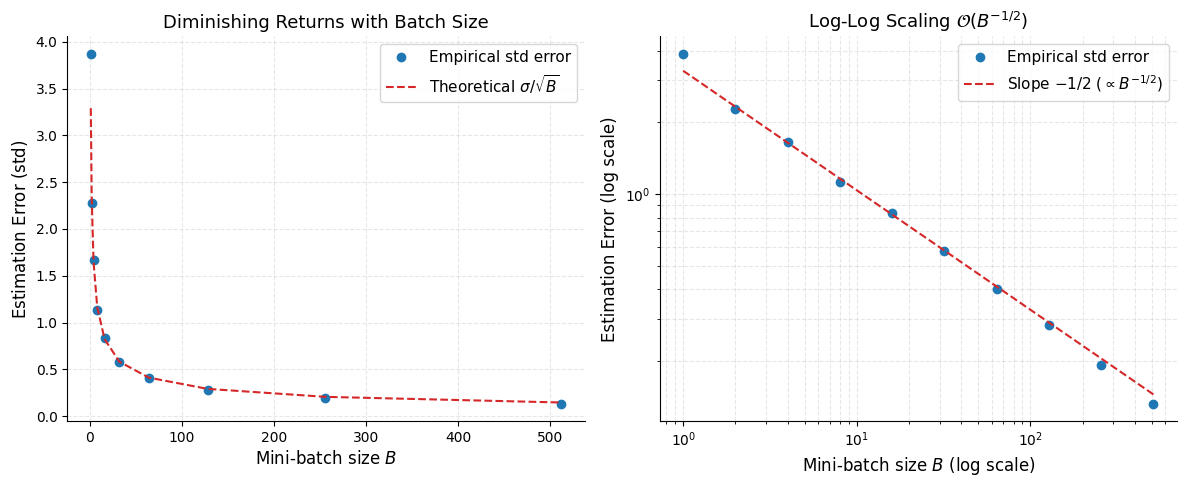

In [3]:
# 7.2.4項: ミニバッチ勾配推定誤差の検証 (収穫逓減 sigma / sqrt(B))
rng = np.random.default_rng(42)
N_samples = 2000
W_dim = 4

# 合成線形回帰問題
X_data = rng.normal(size=(N_samples, W_dim))
y_data = X_data @ np.array([1.2, -0.8, 2.5, -1.0]) + rng.normal(scale=0.5, size=N_samples)
w_point = np.zeros(W_dim)

def sample_gradient(w, idx):
    return (np.dot(X_data[idx], w) - y_data[idx]) * X_data[idx]

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
noise_results = compute_gradient_noise_vs_batch_size(
    grad_sample_fn=sample_gradient,
    w=w_point,
    n_samples=N_samples,
    batch_sizes=batch_sizes,
    num_trials=100,
    random_state=42
)

# 図版の生成と保存
fig_mb_path, _ = generate_minibatch_noise_figure()
print(f"Mini-batch noise scaling figure saved: {fig_mb_path}")

# プロット表示
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(noise_results["batch_sizes"], noise_results["empirical_std"], "o", color="#1f77b4", label="Empirical std error")
ax1.plot(noise_results["batch_sizes"], noise_results["theoretical_std"], "--", color="#d62728", label=r"Theoretical $\sigma / \sqrt{B}$")
ax1.set_xlabel("Mini-batch size $B$", fontsize=12)
ax1.set_ylabel(r"Estimation Error ($\mathrm{std}$)", fontsize=12)
ax1.set_title("Diminishing Returns with Batch Size", fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

ax2.loglog(noise_results["batch_sizes"], noise_results["empirical_std"], "o", color="#1f77b4", label="Empirical std error")
ax2.loglog(noise_results["batch_sizes"], noise_results["theoretical_std"], "--", color="#d62728", label=r"Slope $-1/2$ ($\propto B^{-1/2}$)")
ax2.set_xlabel("Mini-batch size $B$ (log scale)", fontsize=12)
ax2.set_ylabel("Estimation Error (log scale)", fontsize=12)
ax2.set_title(r"Log-Log Scaling $\mathcal{O}(B^{-1/2})$", fontsize=13)
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_2_gd_trajectories.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_2_gd_trajectories.png
Gradient descent comparison figure saved: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_2_gd_trajectories.png


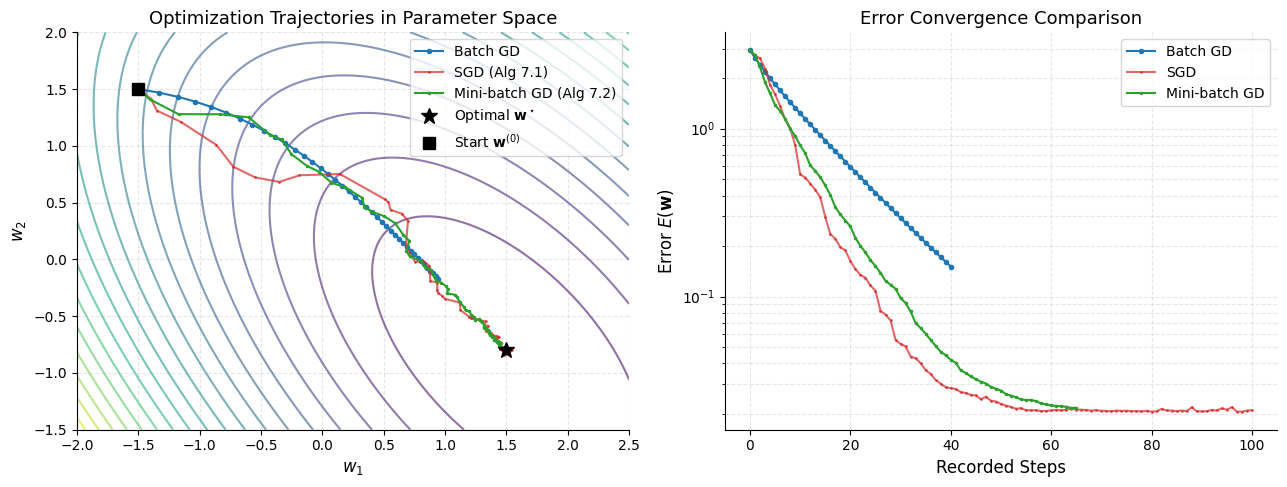

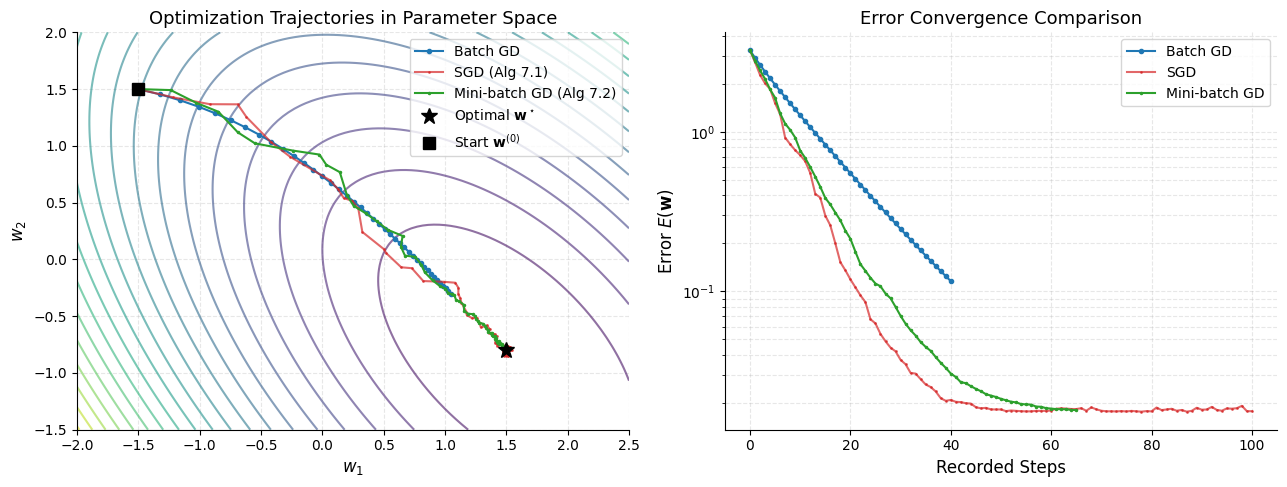

In [4]:
# 7.2.2 - 7.2.4項: バッチGD vs SGD (Alg 7.1) vs ミニバッチGD (Alg 7.2) の軌道比較
fig_gd_path, _ = generate_gd_comparison_figure()
print(f"Gradient descent comparison figure saved: {fig_gd_path}")

# 結果の直接プロット表示
N = 200
w_true = np.array([1.5, -0.8])
X = rng.normal(size=(N, 2))
X[:, 1] = 0.5 * X[:, 0] + 0.8 * X[:, 1]
y = X @ w_true + rng.normal(scale=0.2, size=N)

def err_f(w):
    return 0.5 * float(np.mean((X @ w - y) ** 2))

def batch_g(w):
    return (X.T @ (X @ w - y)) / N

def sample_g(w, n):
    return (np.dot(X[n], w) - y[n]) * X[n]

def mb_g(w, b_idx):
    X_b = X[b_idx]
    y_b = y[b_idx]
    return (X_b.T @ (X_b @ w - y_b)) / len(b_idx)

w0 = np.array([-1.5, 1.5])
h_batch = batch_gradient_descent(w0, batch_g, error_fn=err_f, lr=0.1, max_epochs=40)
h_sgd = stochastic_gradient_descent(w0, sample_g, n_samples=N, error_fn=err_f, lr=0.02, max_epochs=5, shuffle=True, random_state=42, record_every_steps=10)
h_mb = minibatch_gradient_descent(w0, mb_g, n_samples=N, batch_size=16, error_fn=err_f, lr=0.08, max_epochs=10, shuffle=True, random_state=42, record_every_steps=2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
w1_g = np.linspace(-2.0, 2.5, 100)
w2_g = np.linspace(-1.5, 2.0, 100)
W1, W2 = np.meshgrid(w1_g, w2_g)
Z = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        Z[i, j] = err_f(np.array([W1[i, j], W2[i, j]]))

ax1.contour(W1, W2, Z, levels=20, cmap="viridis", alpha=0.6)
ax1.plot(h_batch.weights[:, 0], h_batch.weights[:, 1], "o-", color="#1f77b4", label="Batch GD", markersize=3)
ax1.plot(h_sgd.weights[:, 0], h_sgd.weights[:, 1], ".-", color="#d62728", alpha=0.7, label="SGD (Alg 7.1)", markersize=2)
ax1.plot(h_mb.weights[:, 0], h_mb.weights[:, 1], ".-", color="#2ca02c", label="Mini-batch GD (Alg 7.2)", markersize=3)
ax1.plot(w_true[0], w_true[1], "k*", markersize=12, label=r"Optimal $\mathbf{w}^\star$")
ax1.plot(w0[0], w0[1], "ks", markersize=8, label=r"Start $\mathbf{w}^{(0)}$")
ax1.set_xlabel("$w_1$", fontsize=12)
ax1.set_ylabel("$w_2$", fontsize=12)
ax1.set_title("Optimization Trajectories in Parameter Space", fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

ax2.plot(h_batch.errors, "o-", color="#1f77b4", label="Batch GD", markersize=3)
ax2.plot(h_sgd.errors, ".-", color="#d62728", alpha=0.7, label="SGD", markersize=2)
ax2.plot(h_mb.errors, ".-", color="#2ca02c", label="Mini-batch GD", markersize=3)
ax2.set_xlabel("Recorded Steps", fontsize=12)
ax2.set_ylabel(r"Error $E(\mathbf{w})$", fontsize=12)
ax2.set_title("Error Convergence Comparison", fontsize=13)
ax2.set_yscale("log")
ax2.legend(fontsize=10)
ax2.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


---

## 7.2.5 パラメータの初期化 (Parameter Initialization)

勾配降下法などの反復アルゴリズムでは、探索を開始する初期パラメータ $\mathbf{w}^{(0)}$ の設定が、収束速度や汎化性能に極めて重大な影響を与えます。

### 1. 対称性の破れ (Symmetry Breaking)
同一の入力を受け取る隠れユニット群において、すべての重みを同一の値（例えばゼロ）で初期化した場合を考えます。
このとき、すべてのユニットは完全に同一の活性化を出力し、誤差逆伝播における勾配も完全に同一となります。その結果、すべての重みが同一の値に一斉に更新され続け、複数の隠れユニットが存在しても単一のユニットと同じ関数しか表現できず、冗長（Redundant）となってしまいます。
この対称性を打破（**Symmetry Breaking**）するために、重みはランダムな確率分布からサンプリングして初期化する必要があります。

### 2. He初期化の導出 (He et al., 2015)
ReLU活性化関数（6.17式）を用いる深層ネットワークの第 $l$ 層における線形変換と活性化を考えます：
$$
a_i^{(l)} = \sum_{j=1}^M w_{ij}^{(l-1)} z_j^{(l-1)} \tag{7.19}
$$
$$
z_i^{(l)} = \text{ReLU}(a_i^{(l)}) = \max(0, a_i^{(l)}) \tag{7.20}
$$
ここで $M$ はユニット $i$ に接続する入力ユニット数（ファンイン, Fan-in）です。
重み $w_{ij}$ を平均 0、分散 $\epsilon^2$ のガウス分布 $\mathcal{N}(0, \epsilon^2)$ から独立に初期化し、前層の出力 $z_j^{(l-1)}$ が平均的な分散 $\lambda^2$ をもつと仮定します。

重みと入力が独立であるため、線形変換の期待値はゼロとなります：
$$
\mathbb{E}[a_i^{(l)}] = \sum_{j=1}^M \mathbb{E}[w_{ij}^{(l-1)}] \mathbb{E}[z_j^{(l-1)}] = 0 \tag{7.21}
$$
また、$a_i^{(l)}$ の分散は：
$$
\text{var}[a_i^{(l)}] = \sum_{j=1}^M \text{var}[w_{ij}^{(l-1)}] \mathbb{E}[(z_j^{(l-1)})^2] = M \epsilon^2 \lambda^2
$$
ここで、$a_i^{(l)}$ は平均 0 の対称分布に従うため、ReLU活性化関数によりその半分の領域（$a < 0$）が 0 に切り捨てられます。したがって、出力 $z_j^{(l)}$ の2次モーメント（分散）には係数 $\frac{1}{2}$ が掛かります：
$$
\text{var}[z_j^{(l)}] = \frac{M}{2} \epsilon^2 \lambda^2 \tag{7.22}
$$
層を重ねても信号の分散が発散（Exploding）せず、かつゼロに減衰（Vanishing）しないためには、$\text{var}[z_j^{(l)}] = \lambda^2$ が維持される必要があります：
$$
\frac{M}{2} \epsilon^2 = 1 \implies \epsilon = \sqrt{\frac{2}{M}} \tag{7.23}
$$
これが **He初期化 (He Initialization)** の基本公式です。

### 3. 他の活性化関数とバイアスの初期化
- **Glorot / Xavier 初期化**: $\tanh$ や線形活性化関数では活性化後の分散半減が生じないため、$\epsilon = \sqrt{2 / (M_{\text{in}} + M_{\text{out}})}$ または $\sqrt{1 / M}$ を採用します。
- **バイアスパラメータ**: ReLUユニットでは、初期状態で pre-activation が正となって勾配が消失しないよう、バイアスを $0$ または小さな正の値（0.01など）に初期化することが推奨されます。
- **転移学習 (Transfer Learning)**: 他のタスクで学習済みの重みを利用して初期化するアプローチも極めて重要です。


=== 対称性の破れ (Symmetry Breaking) 検証 ===
ゼロ初期化時の重み行がすべて一致（対称性未破れ）: True
He正規乱数初期化時の重み行が互いに相違（対称性破れ）: True

ゼロ初期化後の最終隠れ重み行列 W1:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

ランダム初期化後の最終隠れ重み行列 W1:
[[ 0.5475  0.1639 -0.4363]
 [ 0.1023  0.1335  0.11  ]
 [ 0.6686  0.19    0.4886]
 [-0.1397  0.2792  0.4229]]


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_2_variance_propagation.png


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_7_2_variance_propagation.png

Variance propagation figure saved: /home/student/Documents/GitHub/my_DeepLearning/7/result/fig_7_2_variance_propagation.png


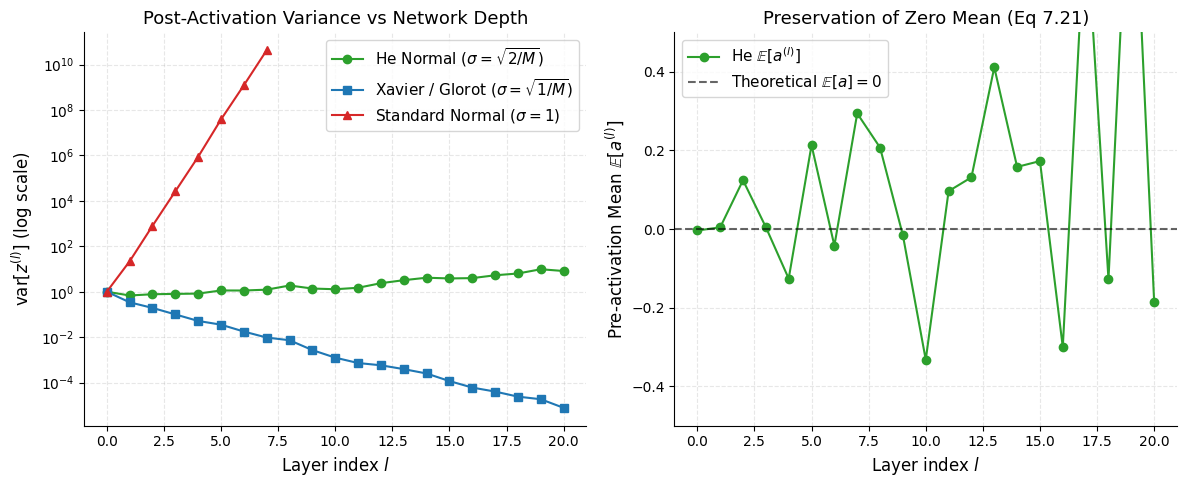

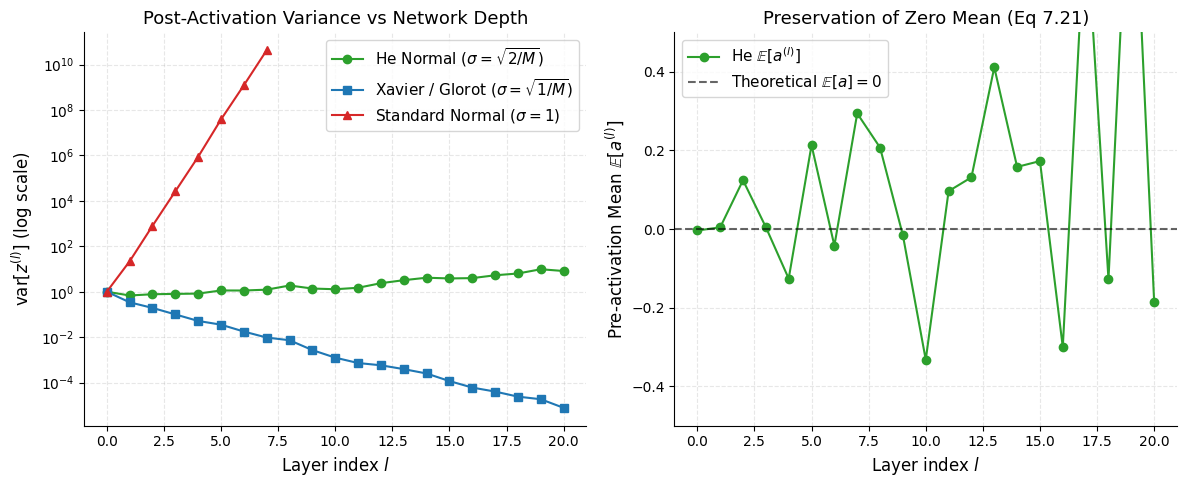

In [5]:
# 7.2.5項: 対称性の破れと深層分散伝播の実験的検証

# 1. 対称性の破れの検証
sym_results = verify_symmetry_breaking(hidden_units=4, input_dim=3, steps=5)
print("=== 対称性の破れ (Symmetry Breaking) 検証 ===")
print(f"ゼロ初期化時の重み行がすべて一致（対称性未破れ）: {sym_results['zero_rows_identical']}")
print(f"He正規乱数初期化時の重み行が互いに相違（対称性破れ）: {sym_results['rand_rows_distinct']}")
print("\nゼロ初期化後の最終隠れ重み行列 W1:")
print(np.round(sym_results['zero_final_w1'], 4))
print("\nランダム初期化後の最終隠れ重み行列 W1:")
print(np.round(sym_results['rand_final_w1'], 4))

# 2. 深層ReLUネットワークにおける分散伝播シミュレーション
fig_var_path, _ = generate_variance_propagation_figure()
print(f"\nVariance propagation figure saved: {fig_var_path}")

depth = 20
width = 64
res_he = simulate_variance_propagation(depth=depth, width=width, init_type="he", activation="relu")
res_xavier = simulate_variance_propagation(depth=depth, width=width, init_type="xavier", activation="relu")
res_std = simulate_variance_propagation(depth=depth, width=width, init_type="standard_normal", activation="relu")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 活性化値の分散推移
ax1.semilogy(res_he["layers"], res_he["post_act_vars"], "o-", color="#2ca02c", label=r"He Normal ($\sigma = \sqrt{2/M}$)")
ax1.semilogy(res_xavier["layers"], res_xavier["post_act_vars"], "s-", color="#1f77b4", label=r"Xavier / Glorot ($\sigma = \sqrt{1/M}$)")
ax1.semilogy(res_std["layers"][:8], res_std["post_act_vars"][:8], "^-", color="#d62728", label=r"Standard Normal ($\sigma = 1$)")
ax1.set_xlabel("Layer index $l$", fontsize=12)
ax1.set_ylabel(r"$\mathrm{var}[z^{(l)}]$ (log scale)", fontsize=12)
ax1.set_title("Post-Activation Variance vs Network Depth", fontsize=13)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=11)

# Pre-activation の期待値推移 (Eq 7.21)
ax2.plot(res_he["layers"], res_he["pre_act_means"], "o-", color="#2ca02c", label=r"He $\mathbb{E}[a^{(l)}]$")
ax2.axhline(0.0, linestyle="--", color="black", alpha=0.6, label=r"Theoretical $\mathbb{E}[a] = 0$")
ax2.set_xlabel("Layer index $l$", fontsize=12)
ax2.set_ylabel(r"Pre-activation Mean $\mathbb{E}[a^{(l)}]$", fontsize=12)
ax2.set_title(r"Preservation of Zero Mean (Eq 7.21)", fontsize=13)
ax2.set_ylim(-0.5, 0.5)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.show()


---

## 7.2節のまとめと次節（7.3節 収束性）への展望

本節（7.2節）では、ニューラルネットワークの最適化における中核アルゴリズムと統計数理を学びました：
1. **勾配情報と逆伝播の優位性**: 局所2次曲面を解くのに必要な計算量が、関数評価のみの $\mathcal{O}(W^3)$ から勾配利用の $\mathcal{O}(W^2)$ へと大幅に削減される数理的背景を確認しました。
2. **バッチGD vs SGD vs ミニバッチGD**:
   - 全データを用いるバッチ法は安定しているが大規模データで非効率。
   - 逐次更新を行うSGD（**アルゴリズム 7.1**）は冗長性を排除し、局所最小値を脱出可能。
   - ミニバッチSGD（**アルゴリズム 7.2**）は標準誤差 $\sigma / \sqrt{B}$ の収穫逓減とハードウェア並列性を両立する現代標準の解法。
3. **パラメータ初期化**:
   - ゼロ初期化では対称性が破れず全ユニットが同一の更新を行ってしまう。
   - ReLU活性化関数に対しては、信号の分散を維持するために **He初期化** $\epsilon = \sqrt{2/M}$ (Eq 7.23) が不可欠。

### 次節（7.3節 収束性）への接続
勾配降下法を長細い谷（Ravine/Valley）のような異方的な曲率をもつ誤差曲面に適用すると、負の勾配ベクトルが最小値の方向を向かず、谷を横切る振動が生じて進行が著しく遅滞します（Figure 7.3）。
次節（7.3節）では、この振動を抑制して進行方向を加速する**モーメンタム法 (Momentum)**、学習率スケジューリング、そして深層学習の標準最適化器である **RMSProp** や **Adam (Algorithm 7.4)** を学びます。
